## Bose-Hubbard Library to study Unitary evolution

#### Imports

In [1]:
import src.bosehubbard.bosehubbard as bh
import numpy as np
import scipy
import scipy.sparse as sparse
from pyexpokit import expmv
from tqdm import tqdm
import matplotlib.pyplot as plt

from typing import List

The HyperParameter of this class are quite simple. Following the Bose Hubbard Hamiltonian 

$\hat{H}= \sum_{i,j} J_{ij} b^{\dagger}_i b_j + \sum_i \Omega_i b^{\dagger}_i b_i + U \sum_i b^{\dagger}_i b^{\dagger}_i b_i b_i$

where $J_{ij}= J \Lambda_{ij}$, and $\Lambda_{ij}$ is the adjacency matrix. These parameters are defined as int value for the number of lattice sites $l$, $J$ as a float value, a list for each sites of onsite energies $[\Omega_i]_i$ and the links list defined as a list of lists $[[i,j],J]_{i \sim j}$

In [2]:
l: int=10
j: float=1.
omegas: List = [0]*l
# we define a 1D chain in pbc
links: List = [[i, (i+1) % l, j] for i in range(l)]
U:float = 0



The Bose-Hubbard model class is defined. This class has the attribute hopping that gives you the $J_{ij}$

In [3]:
# We define the Bose-Hubbard Model
model = bh.Model(omegas, links, U)

print(r'J_{ij}=',model.hopping,'\n')

J_{ij}= [[0. 1. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 1. 0.]] 



The Hamiltonian is built up when the numbersector is defined. The number sector defines the subspace in the Fock space restricted to the fixed number of total particle. In this case we consider the single particle sector. 


In [5]:
model_single_particle=model.numbersector(1)




An attribute of the numbersector subclass is the hamiltonian. This is encoded in the scipy sparse matrix (in Compressed Sparse Row format). The Hamiltonian is defined respect the basis numbersector.basis.vs

In [8]:
model_single_particle.hamiltonian

<10x10 sparse matrix of type '<class 'numpy.float64'>'
	with 20 stored elements in Compressed Sparse Row format>

The basis can be shown by using the basis subclass. With numbersector.basis.vs

In [9]:
model_single_particle.basis.vs

array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])

One of the most important 

#### The basis and how we can project each eigenstate

In [10]:
print(model_single_particle.basis.index(np.array([0,0,1,0,0,0,0,0,0,0])))


psi_0=np.zeros(model_single_particle.basis.vs.shape[0])

psi_0[0]=1. # 1,0,0 initialization

hamiltonian=model_single_particle.hamiltonian
print(hamiltonian)

2
  (0, 1)	1.0
  (0, 9)	1.0
  (1, 0)	1.0
  (1, 2)	1.0
  (2, 1)	1.0
  (2, 3)	1.0
  (3, 2)	1.0
  (3, 4)	1.0
  (4, 3)	1.0
  (4, 5)	1.0
  (5, 4)	1.0
  (5, 6)	1.0
  (6, 5)	1.0
  (6, 7)	1.0
  (7, 6)	1.0
  (7, 8)	1.0
  (8, 7)	1.0
  (8, 9)	1.0
  (9, 0)	1.0
  (9, 8)	1.0


 Let's study the dynamics of our initial state $\ket{\Psi}=\ket{1} \bigotimes_{i=2}^{L} \ket{0}_i$

fixing a time step $\Delta t$

In [12]:
nstep=1000
time=np.linspace(0.,10.*j,nstep)
dt=time[1]-time[0]
t_bar=tqdm(enumerate(time))


0it [00:00, ?it/s]

Time evolution

In [ ]:
psi=np.zeros((nstep,psi_0.shape[0]),dtype=np.complex128)
psi_t=psi_0.copy()
for i,t in enumerate(time):
    psi[i,:]=psi_t  
    psi_t=expmv(dt,-1j*hamiltonian,psi_t)
    print(np.linalg.norm(psi_t))
    


/opt/anaconda3/envs/qutip_env/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


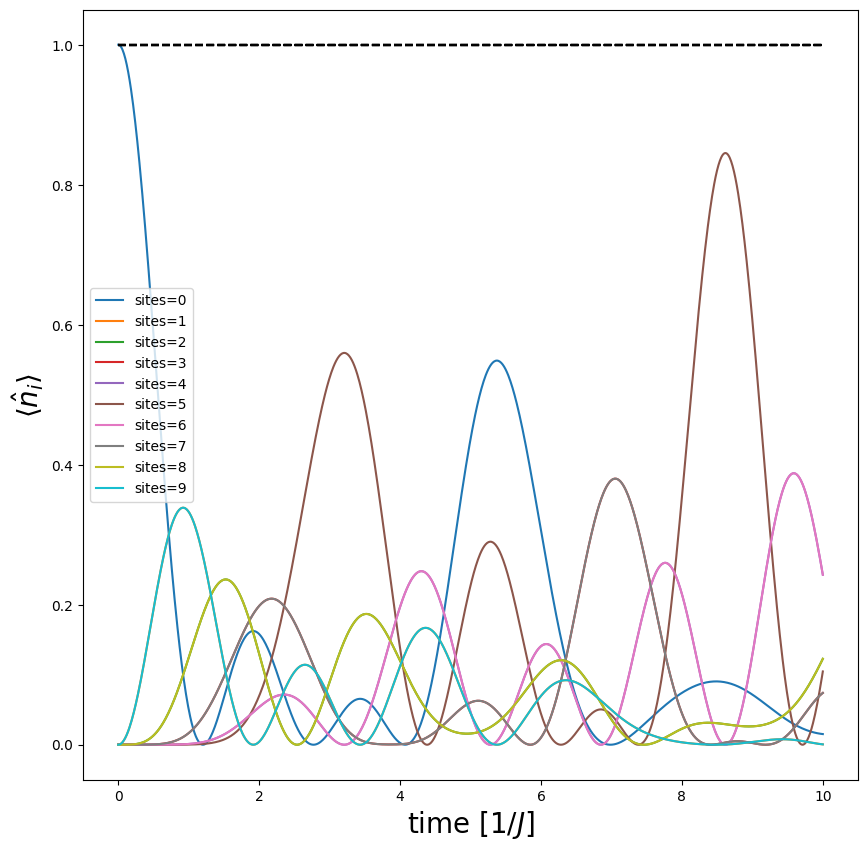

In [14]:
n_occupation=np.conjugate(psi)*psi

np.save('data/for_gerard/l_10_pbc_occupation_number_j_1_omega_0_u_0',n_occupation)
plt.figure(figsize=(10,10))
for i in range(l):
    plt.plot(time,n_occupation[:,i],label=f'sites={i}')
    plt.plot(time,np.sum(n_occupation,axis=-1),color='black',linestyle='--')
plt.xlabel(r'time $[1/J]$',fontsize=20)
plt.ylabel(r'$\langle{\hat{n}_i}\rangle$',fontsize=20)
plt.legend()
plt.show()

We build up the occupation number algorithm

We need to compute $\braket{\hat{n_i}}= \sum_j |a_j|^2 e_j[i]$. With $e_j[i]$ we means the values at the site $i-th$ of the tensor product basis of our state $e_j$

The code

In [10]:
def occupation_number(psi:np.ndarray,basis:np.ndarray,size:int):
    n=np.zeros(size)
    for i in range(size):
        n[i]=np.einsum('j,j,j->',np.conjugate(psi),psi,basis[:,i])
    return n
    
        

### The Lieb Lattice

#### Imports

In [2]:
from typing import List
import numpy as np
import src.bosehubbard.bosehubbard as bh
import numpy as np
import scipy
import scipy.sparse as sparse
from pyexpokit import expmv
from tqdm import tqdm

import matplotlib.pyplot as plt

#### Define a routine that initialize the hopping connections in the lattice

In [39]:
def lieb_lattice(hopping_value:int,linear_dimension:int,):
    main_sites:int=linear_dimension**2
    print(main_sites)
    links:List=[]
    for j in range(linear_dimension):
        for i in range(linear_dimension):
            for a in range(2):
                # connections in the unit cell
                links.append([3*(linear_dimension*j+i)+a,3*(linear_dimension*j+i)+a+1,hopping_value])
            
            if j!=linear_dimension-1:
                links.append([3*(linear_dimension*j+i)+1,3*(linear_dimension*(j+1)+i),hopping_value])
            if i!=linear_dimension-1:
                links.append([3*(linear_dimension*j+i)+2,3*(linear_dimension*j+i+1)+1,hopping_value])

    return links

def occupation_number(psi:np.ndarray,basis:np.ndarray,size:int)->np.ndarray:
    n=np.zeros((psi.shape[0],size))
    print(basis.shape)
    for i in range(size):
        n[:,i]=np.einsum('tj,tj,j->t',np.conjugate(psi),psi,basis[:,i])
    return n
            

Check the adjacency matrix in a case $N=27$ and $J=1.$ 

In [4]:
links=lieb_lattice(hopping_value=1.,linear_dimension=3)
print(links)

9
[[0, 1, 1.0], [1, 2, 1.0], [1, 9, 1.0], [2, 4, 1.0], [3, 4, 1.0], [4, 5, 1.0], [4, 12, 1.0], [5, 7, 1.0], [6, 7, 1.0], [7, 8, 1.0], [7, 15, 1.0], [9, 10, 1.0], [10, 11, 1.0], [10, 18, 1.0], [11, 13, 1.0], [12, 13, 1.0], [13, 14, 1.0], [13, 21, 1.0], [14, 16, 1.0], [15, 16, 1.0], [16, 17, 1.0], [16, 24, 1.0], [18, 19, 1.0], [19, 20, 1.0], [20, 22, 1.0], [21, 22, 1.0], [22, 23, 1.0], [23, 25, 1.0], [24, 25, 1.0], [25, 26, 1.0]]


#### Define the Bose-Hubbard model

In [21]:
linear_dimension:int=7
hopping_energy:float=1.
omegas = [0]*(3*linear_dimension**2)
links:List=lieb_lattice(hopping_value=hopping_energy,linear_dimension=linear_dimension)
U:float = 0

model = bh.Model(omegas, links, U)



49


Consider the single particle sector

In [22]:
model_single_particle=model.numbersector(1)
hamiltonian=model_single_particle.hamiltonian

(147, 147)


#### Study the dynamics of an Edge State

Initialize the Edge states

In [29]:
localized_states:List=[]
for i in range(linear_dimension): # y coordinate of the main lattice
    for j in range(linear_dimension): # x coordinate of the main lattice
        localized_states.append((3*(i*linear_dimension+j),1.)) # first mode in the unit cell
        localized_states.append((3*(i*linear_dimension+j)+2,-1.)) # last mode in the unit cell

localized_states:List=[]
i=1
j=1

localized_states.append((3*(i*linear_dimension+j),1.)) # first mode in the unit cell
localized_states.append((3*(i*linear_dimension+j)+2,-1.)) # last mode in the unit cell

i=1
j=2
localized_states.append((3*(i*linear_dimension+j),1.)) # first mode in the unit cell

i=0
j=1
localized_states.append((3*(i*linear_dimension+j)+2,-1.)) # last mode in the unit cell




print(localized_states)

# initialization of the state
# psi0=np.zeros(3*linear_dimension**2)


# for idx,value in localized_states:
#     set_index=np.zeros(3*linear_dimension**2)
#     set_index[idx]=1
#     index=model_single_particle.basis.index(set_index)
#     psi0[index]=value

psi0=np.zeros(3*linear_dimension**2)

idx,value=localized_states[0]
set_index=np.zeros(3*linear_dimension**2)
set_index[idx]=1
index=model_single_particle.basis.index(set_index)
psi0[index]=value

print(localized_states[0])
psi0=psi0/np.linalg.norm(psi0)

[(24, 1.0), (26, -1.0), (27, 1.0), (5, -1.0)]
(24, 1.0)


Evolution hyperparameters

In [30]:
nstep=1000
time=np.linspace(0.,50.*hopping_energy,nstep)
dt=time[1]-time[0]
t_bar=tqdm(enumerate(time))

0it [11:07, ?it/s]


Evolution via Matrix exponentiation

In [31]:
psi=np.zeros((nstep,psi0.shape[0]),dtype=np.complex128)
psi_t=psi0.copy()
for i,t in enumerate(time):
    psi[i,:]=psi_t  
    psi_t=expmv(dt,-1j*hamiltonian,psi_t)
    

Compute the occupation number and check the results

In [ ]:


fidelity:np.ndarray=np.einsum('ti,i->t',np.conjugate(psi),psi0)

plt.figure(figsize=(10,10))
plt.plot(time,1-fidelity,color='black',linewidth=10)
plt.xlabel(r'$t[1/J]$',fontsize=40)
plt.ylabel(r'$1-F$',fontsize=40)
#plt.loglog()
plt.tick_params(
            top=True,
            right=True,
            labeltop=False,
            labelright=False,
            direction="in",
            labelsize=30,
            width=5,
        )
plt.tick_params(
            which='minor',
            top=True,
            right=True,
            labeltop=False,
            labelright=False,
            direction="in",
            labelsize=0,
            width=1,
            length=2
            
        )
plt.show()



(147, 147)


/tmp/ipykernel_2834360/1848254876.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  n[:,i]=np.einsum('tj,tj,j->t',np.conjugate(psi),psi,basis[:,i])


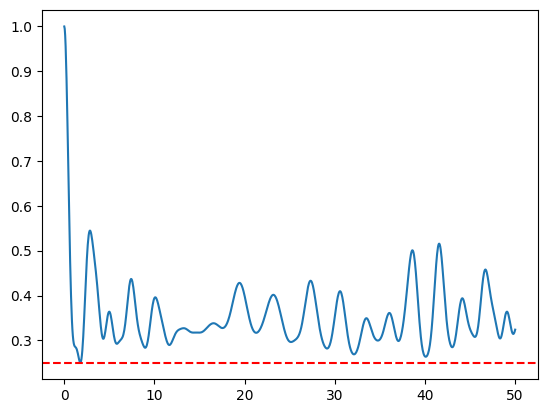

In [42]:
n_occupation:np.ndarray=occupation_number(psi=psi,basis=model_single_particle.basis.vs,size=3*linear_dimension**2)

n_tot=np.zeros(n_occupation.shape[0])
for idx,_ in localized_states:
    n_tot=n_tot+n_occupation[:,idx]

plt.plot(time,n_tot)
plt.axhline(y=0.25,color='red',linestyle='--')
plt.show()
    